# Week 10 Visual Companion: Data Drift and Monitoring

This notebook is a visual companion to the Week 10 lecture.

It focuses on three things:

1. Start with plots before statistical tests
2. Revisit the main figures used in the slides
3. Build intuition for data drift, concept drift, and label drift


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')
ROOT = Path.cwd().resolve()
if not (ROOT / 'slides').exists():
    for parent in ROOT.parents:
        if (parent / 'slides').exists():
            ROOT = parent
            break
IMG = ROOT / 'slides' / 'images' / 'week10'
np.random.seed(42)

print('Repo root:', ROOT)
print('Image folder:', IMG)

Repo root: /Users/nipun/git/stt-ai-teaching
Image folder: /Users/nipun/git/stt-ai-teaching/slides/images/week10


## Part 1: Step 0 — Always Start With a Plot

Before running KS test, PSI, or any other formal test, compare training and production visually.

This is often the fastest way to notice that something changed.


/var/folders/1x/wmgn24mn1bbd2vgbqlk98tbc0000gn/T/ipykernel_76299/447617117.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([train_sqft, prod_sqft], labels=['Training', 'Production'])


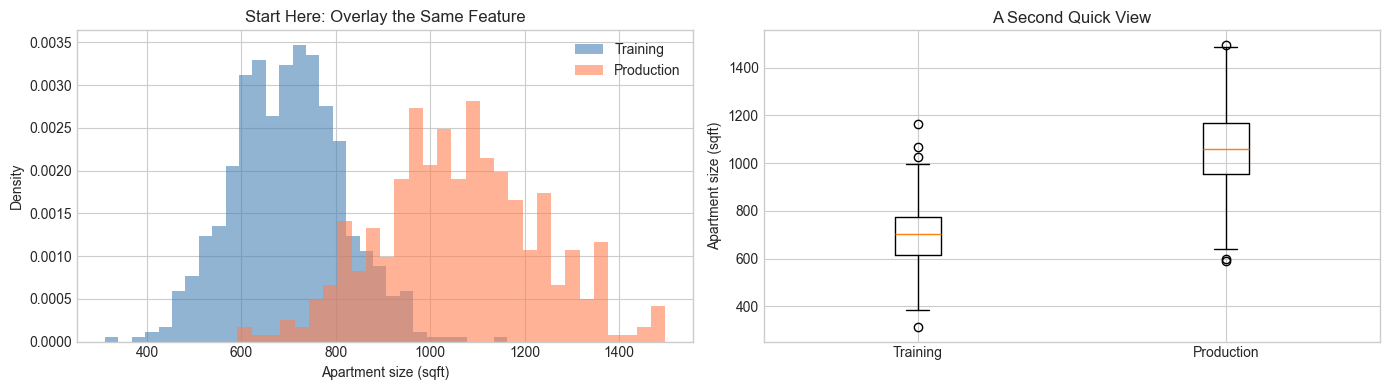

In [2]:
# Example: apartment size distribution changed over time
train_sqft = np.random.normal(700, 120, 600).clip(300, 1200)
prod_sqft = np.random.normal(1050, 170, 400).clip(400, 1800)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_sqft, bins=30, alpha=0.6, label='Training', color='steelblue', density=True)
axes[0].hist(prod_sqft, bins=30, alpha=0.6, label='Production', color='coral', density=True)
axes[0].set_title('Start Here: Overlay the Same Feature')
axes[0].set_xlabel('Apartment size (sqft)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].boxplot([train_sqft, prod_sqft], labels=['Training', 'Production'])
axes[1].set_title('A Second Quick View')
axes[1].set_ylabel('Apartment size (sqft)')

plt.tight_layout()
plt.show()

What to notice:

- the production distribution is shifted to the right
- the median is higher
- the spread is also different

At this stage, we are not proving anything yet. We are building intuition.


## Part 2: Car Price Example from the Lecture

The lecture uses a used-car example because it is easy to understand:

- training data mostly contains lower-mileage cars
- production data later contains higher-mileage cars
- the task stays the same: predict car price


### Slide figure: car price scatter

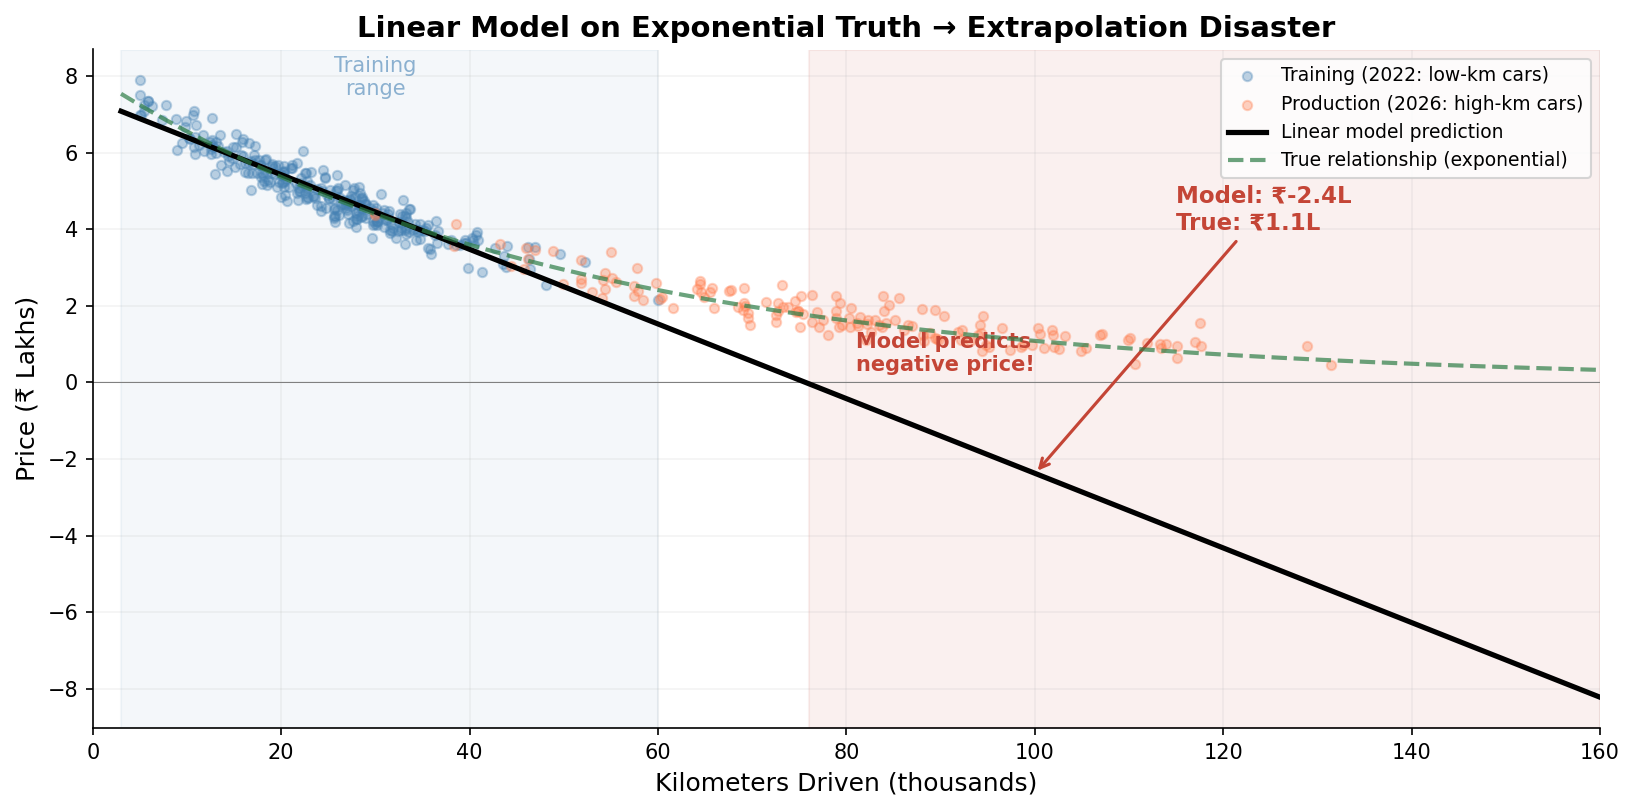

In [3]:
display(Markdown('### Slide figure: car price scatter'))
display(Image(filename=str(IMG / 'car_price_scatter.png')))


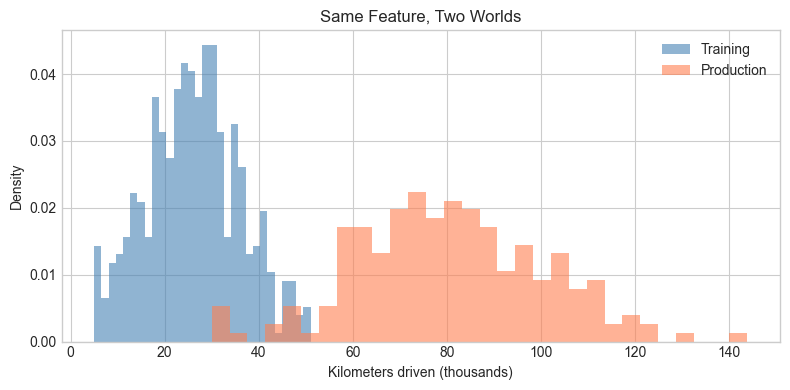

In [4]:
# The same example, shown as a simple distribution comparison
km_train = np.random.normal(25000, 10000, 500).clip(5000, 60000)
km_prod = np.random.normal(80000, 20000, 200).clip(30000, 150000)

plt.figure(figsize=(8, 4))
plt.hist(km_train / 1000, bins=30, alpha=0.6, label='Training', color='steelblue', density=True)
plt.hist(km_prod / 1000, bins=30, alpha=0.6, label='Production', color='coral', density=True)
plt.xlabel('Kilometers driven (thousands)')
plt.ylabel('Density')
plt.title('Same Feature, Two Worlds')
plt.legend()
plt.tight_layout()
plt.show()

## Part 3: Image and Text Drift

Data drift is not only for tables. It appears in images, audio, and text too.


### Image drift figure

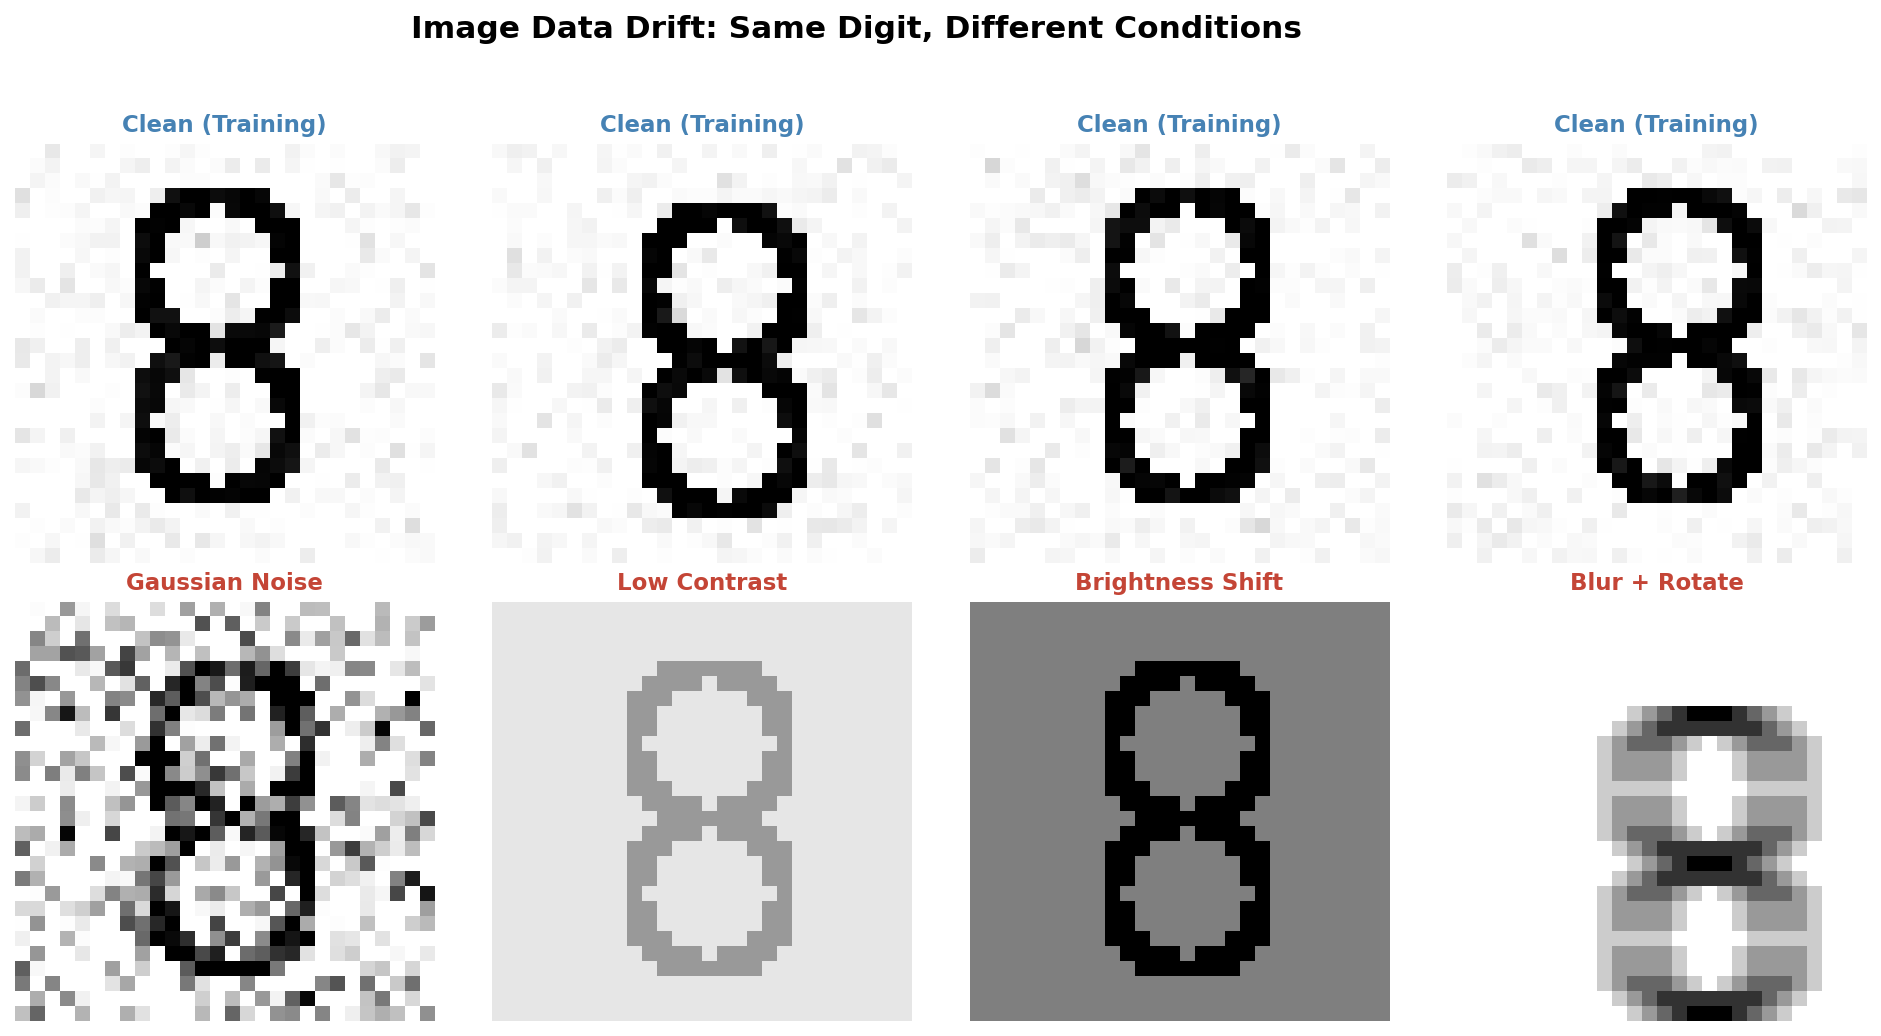

### Image summary-statistics figure

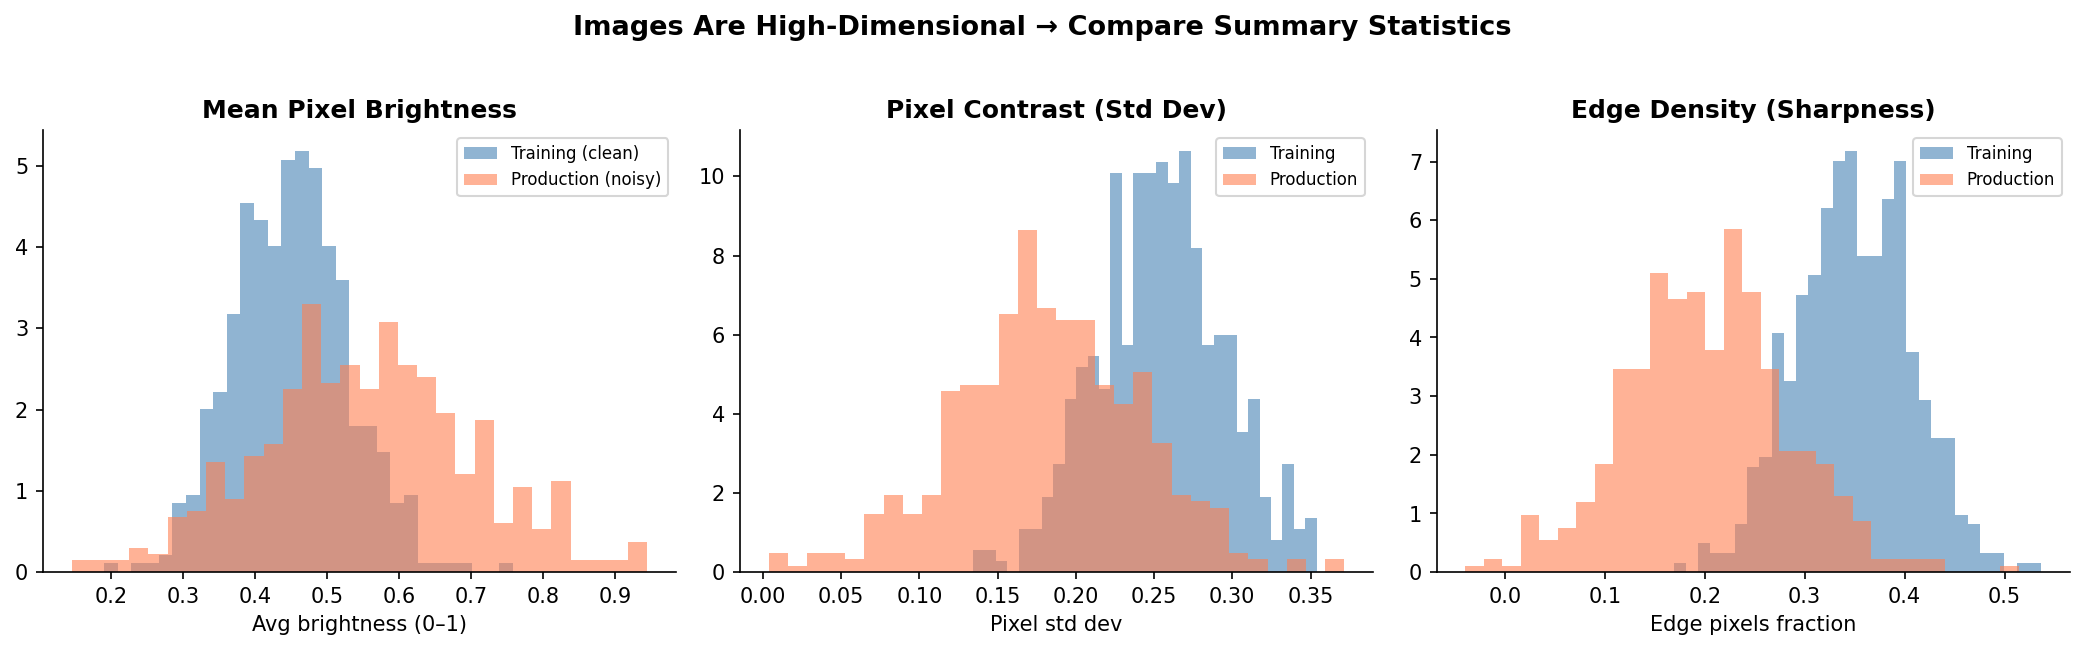

In [5]:
display(Markdown('### Image drift figure'))
display(Image(filename=str(IMG / 'image_drift_example.png')))

display(Markdown('### Image summary-statistics figure'))
display(Image(filename=str(IMG / 'image_drift_pixels.png')))


### Text drift figure

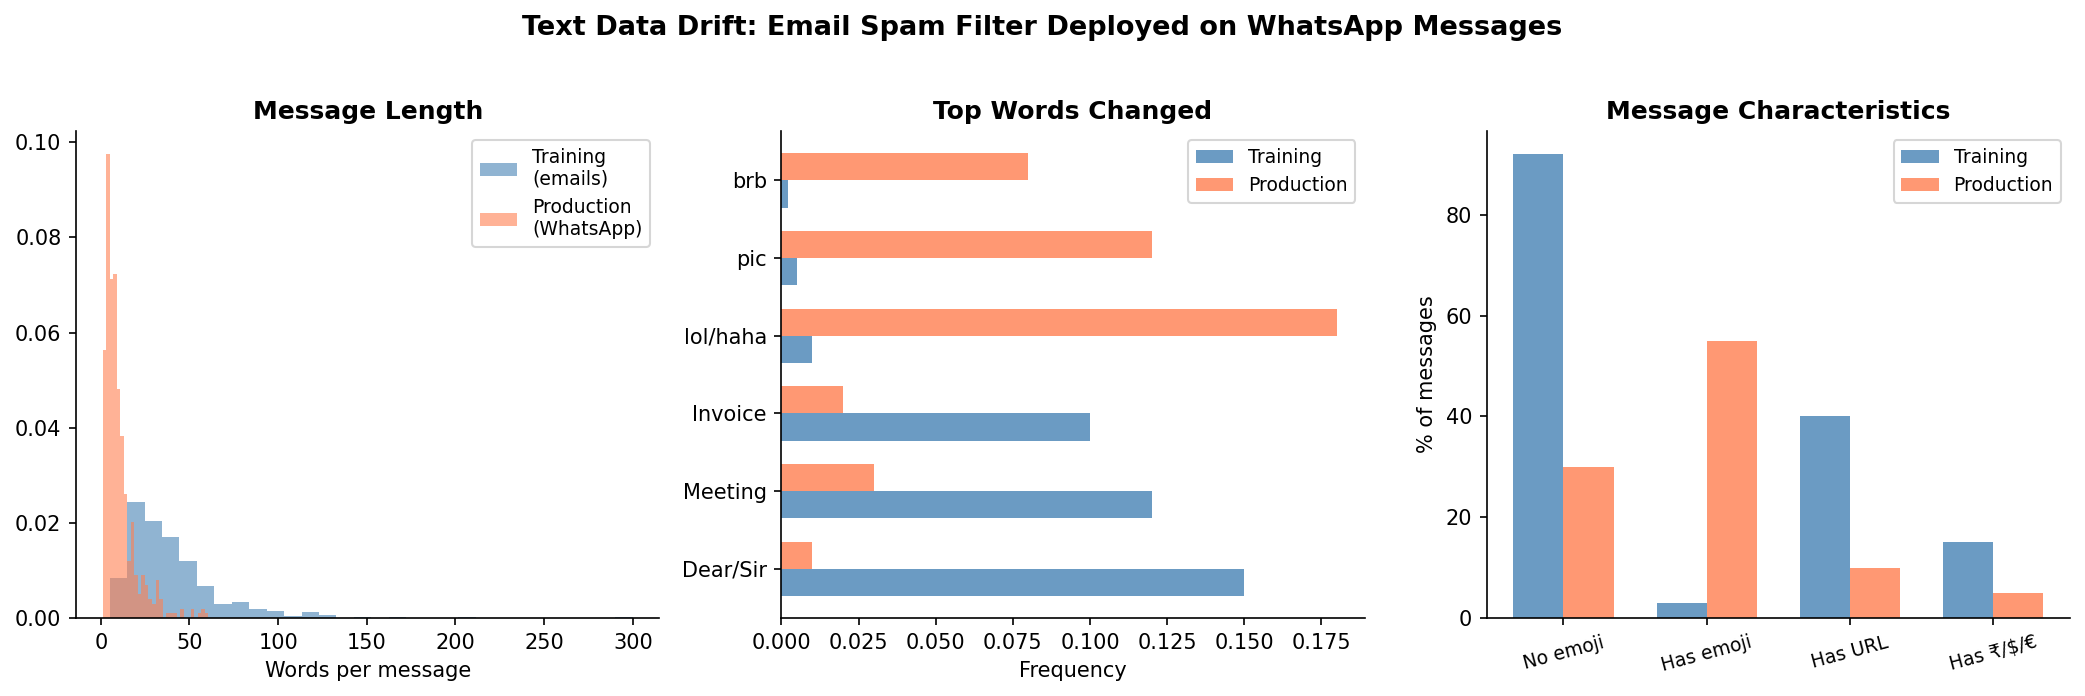

In [6]:
display(Markdown('### Text drift figure'))
display(Image(filename=str(IMG / 'text_drift_example.png')))


Use these questions when you see such figures:

- Did the task stay the same?
- Did the input style change?
- Would an old model still be seeing familiar inputs?


## Part 4: CDF and KS Test Intuition

Once the plot suggests something changed, we move to a formal test.


### CDF intuition

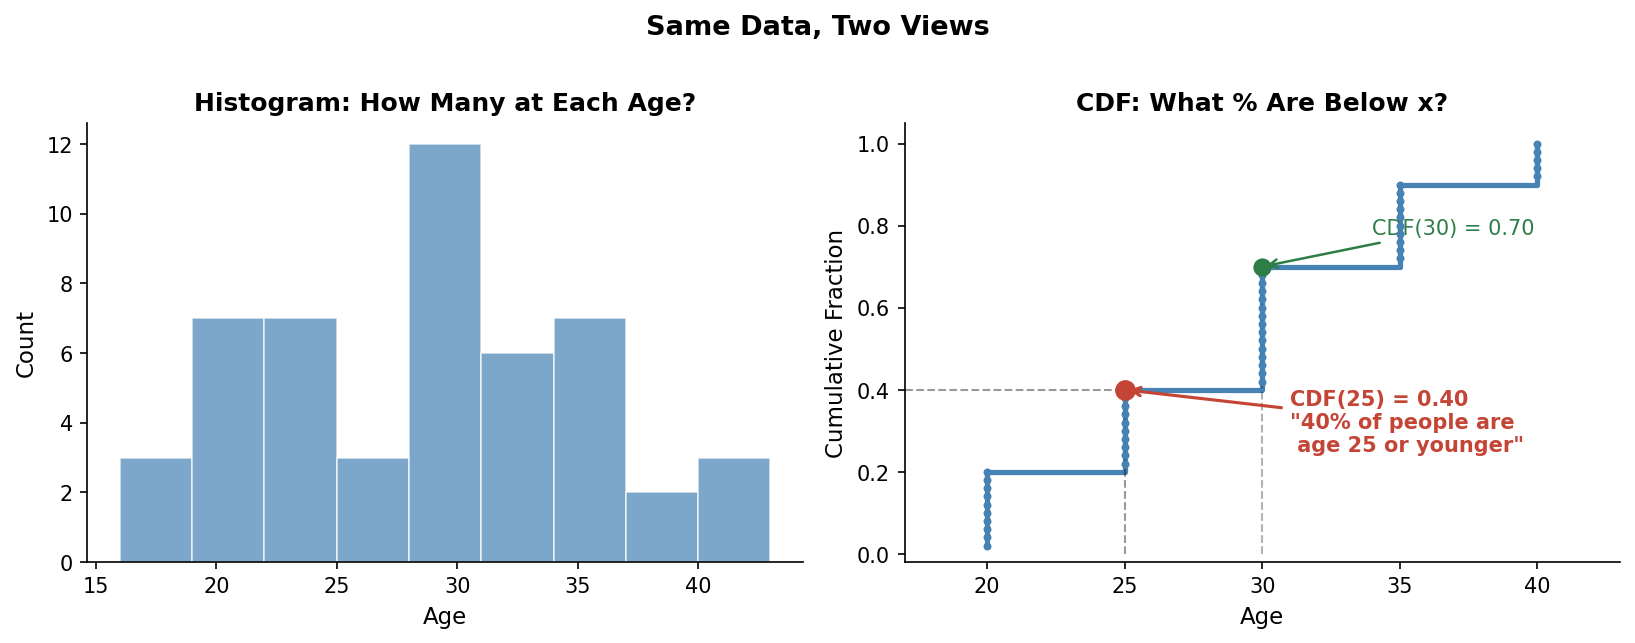

### KS: no-drift vs drift cases

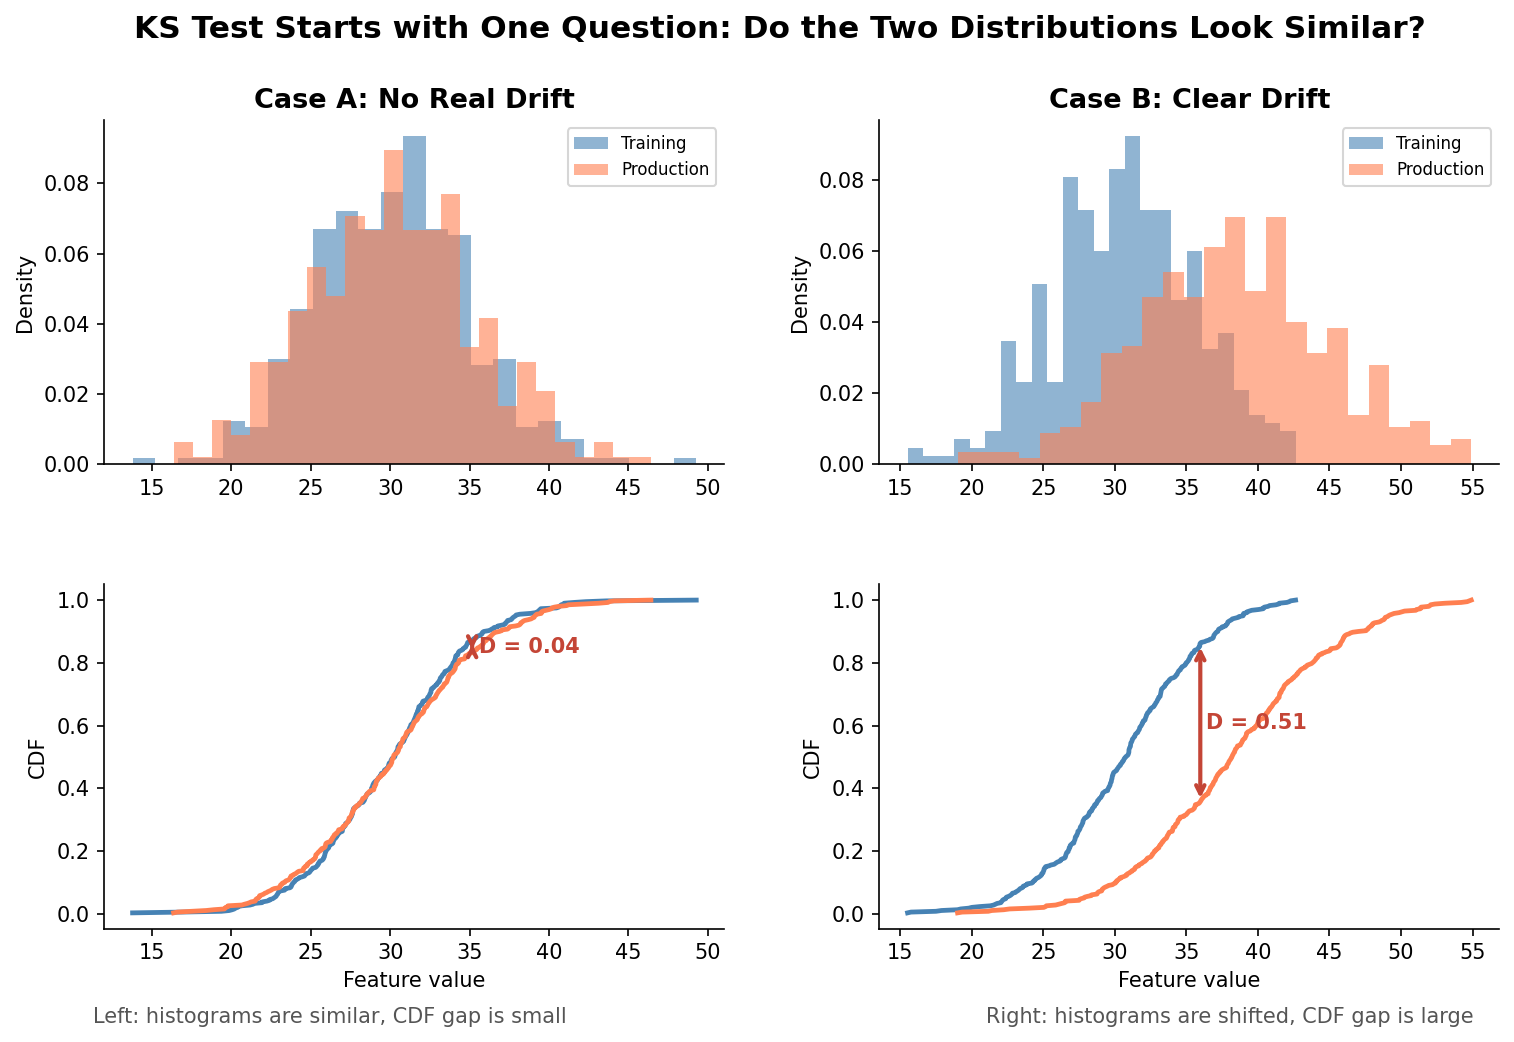

### KS: biggest-gap intuition

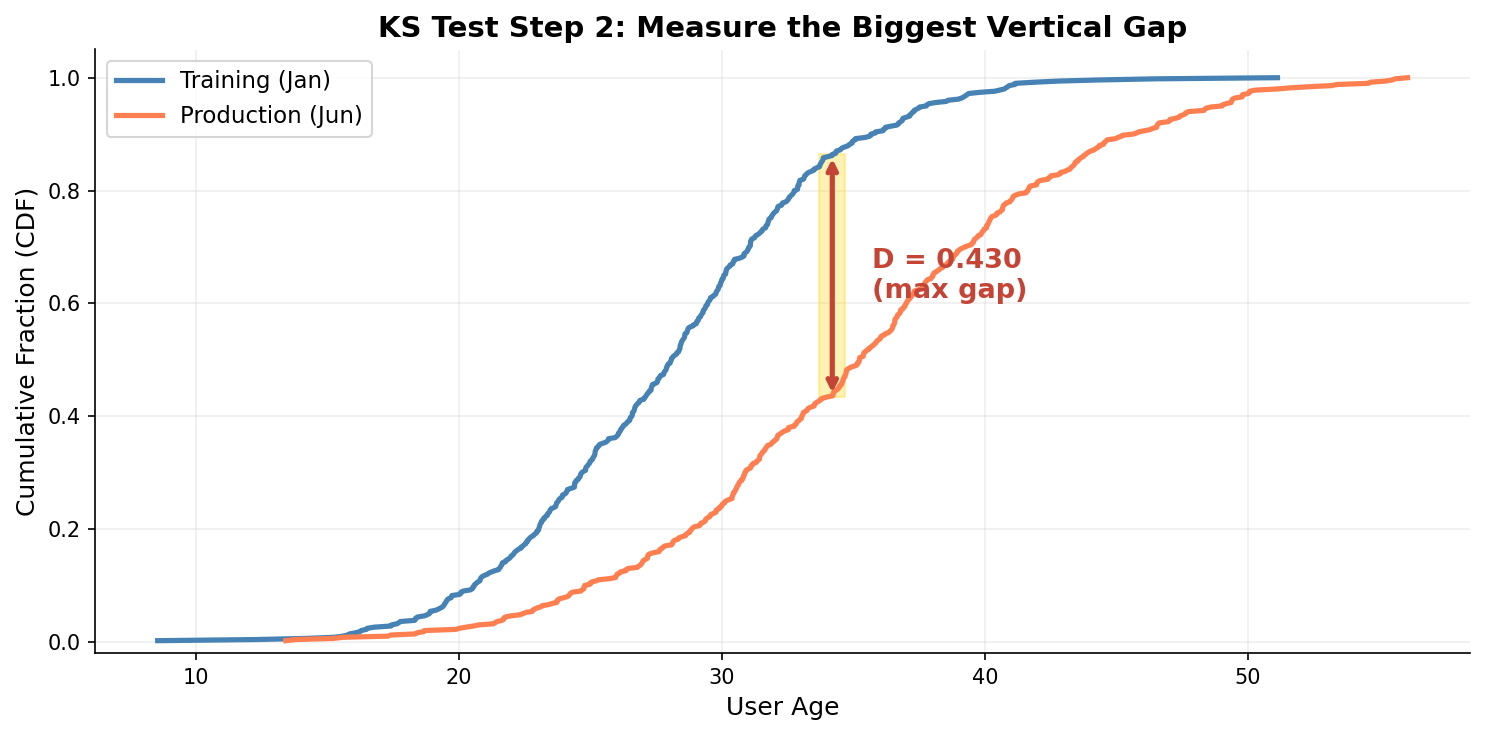

In [7]:
display(Markdown('### CDF intuition'))
display(Image(filename=str(IMG / 'cdf_intuition.png')))

display(Markdown('### KS: no-drift vs drift cases'))
display(Image(filename=str(IMG / 'ks_two_cases.png')))

display(Markdown('### KS: biggest-gap intuition'))
display(Image(filename=str(IMG / 'ks_test_intuition.png')))


## Part 5: Concept Drift and Label Drift Visuals

These are different from data drift.

- concept drift: same input can need a different label later
- label drift: the label mix changes even if the task stays the same


### Concept drift decision-boundary figure

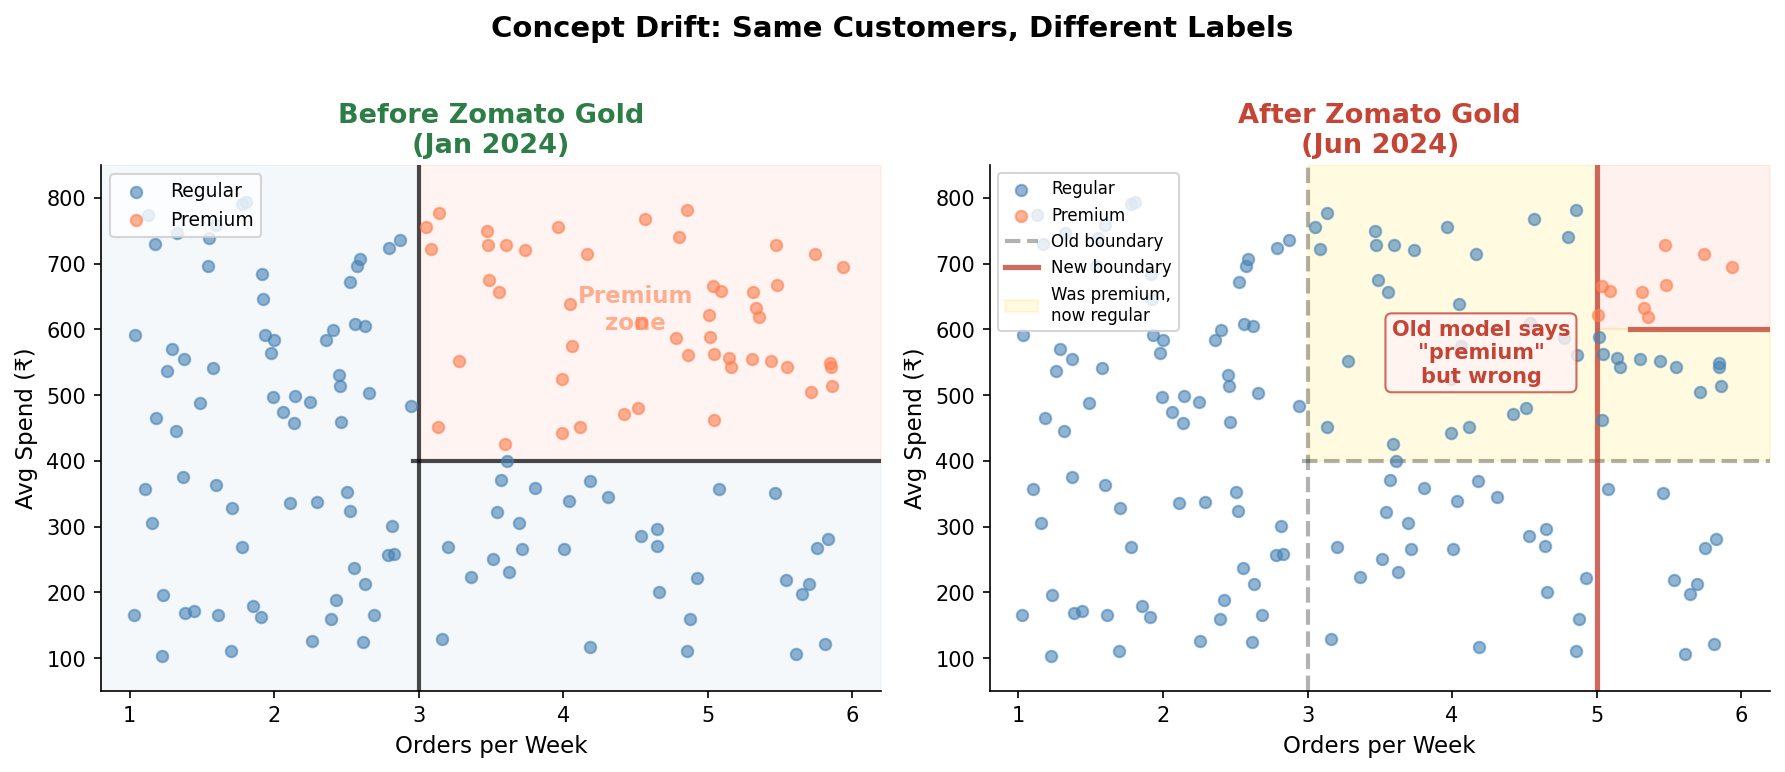

### Concept drift cases figure

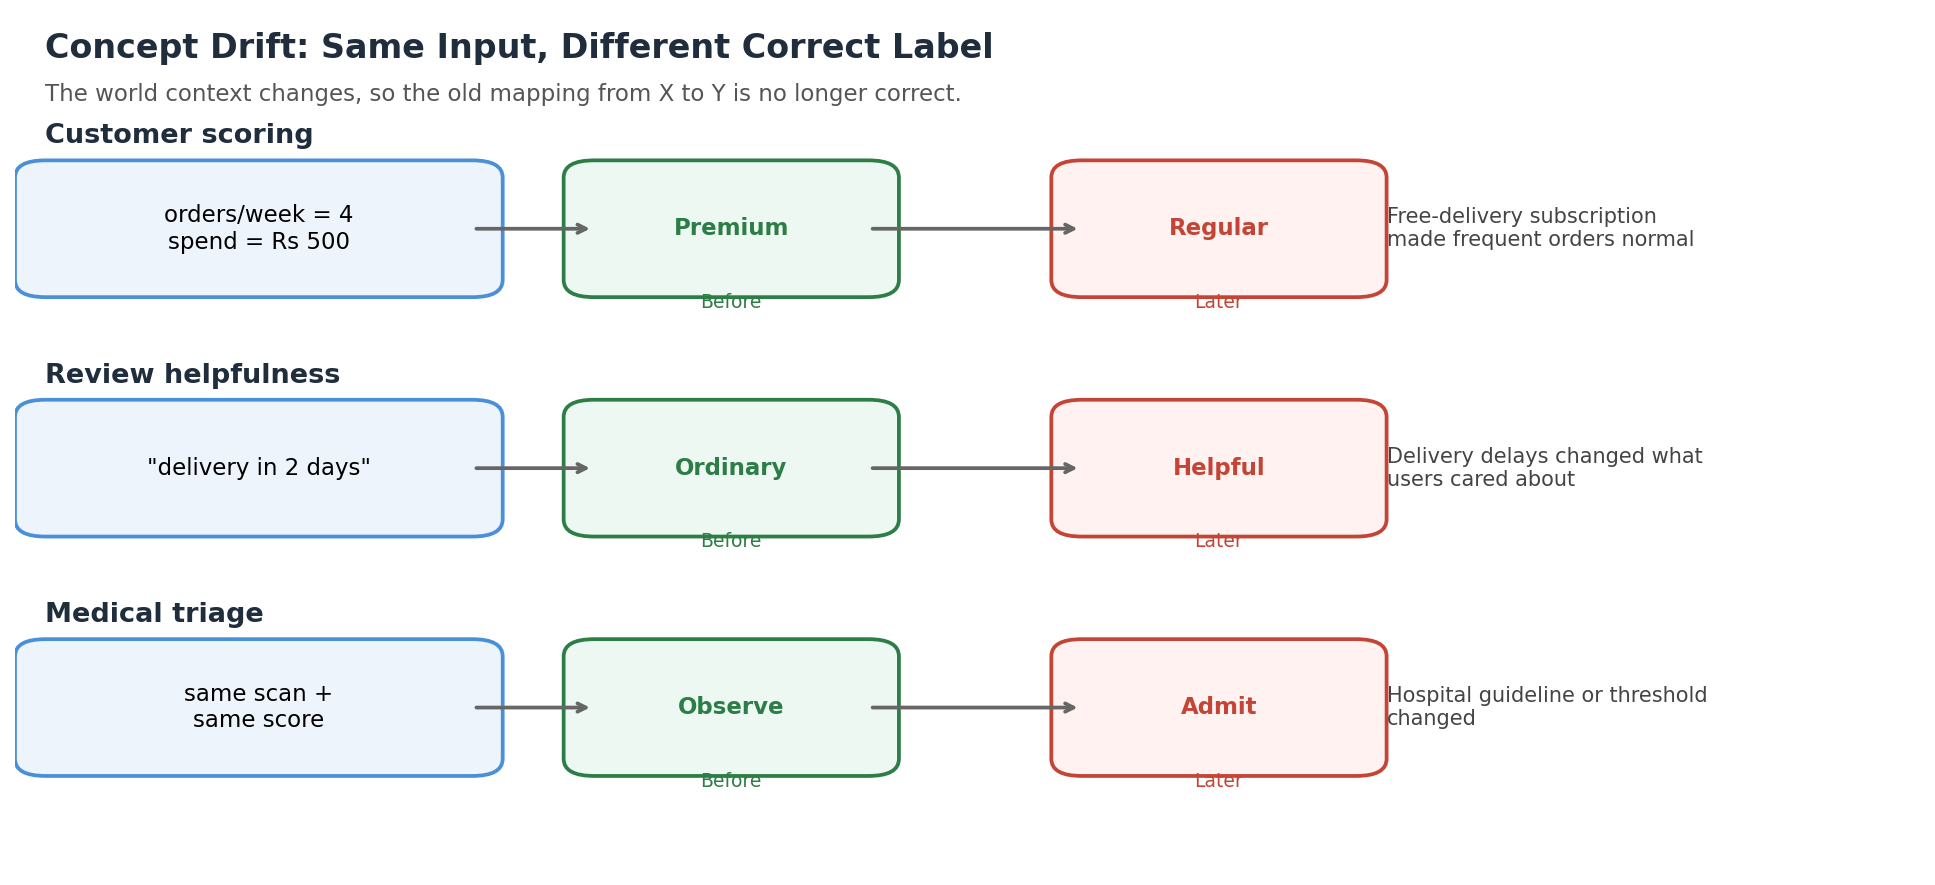

### Label drift figure

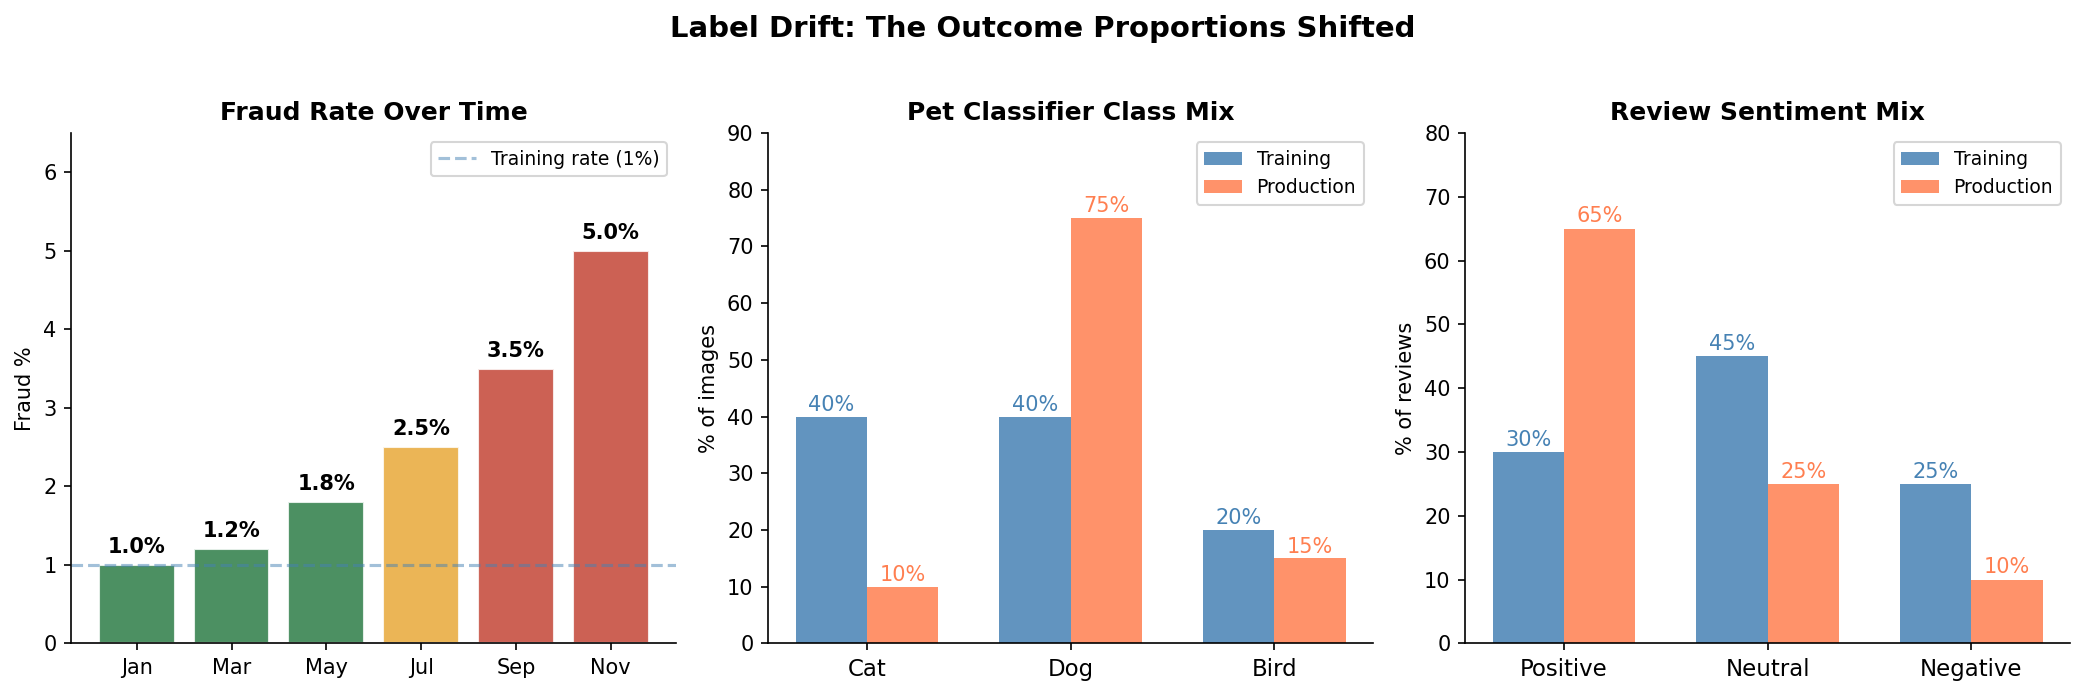

In [8]:
display(Markdown('### Concept drift decision-boundary figure'))
display(Image(filename=str(IMG / 'concept_drift_detailed.png')))

display(Markdown('### Concept drift cases figure'))
display(Image(filename=str(IMG / 'concept_drift_cases.png')))

display(Markdown('### Label drift figure'))
display(Image(filename=str(IMG / 'label_drift_example.png')))


## Part 6: The Three Types at a Glance

This summary figure helps connect the three ideas.


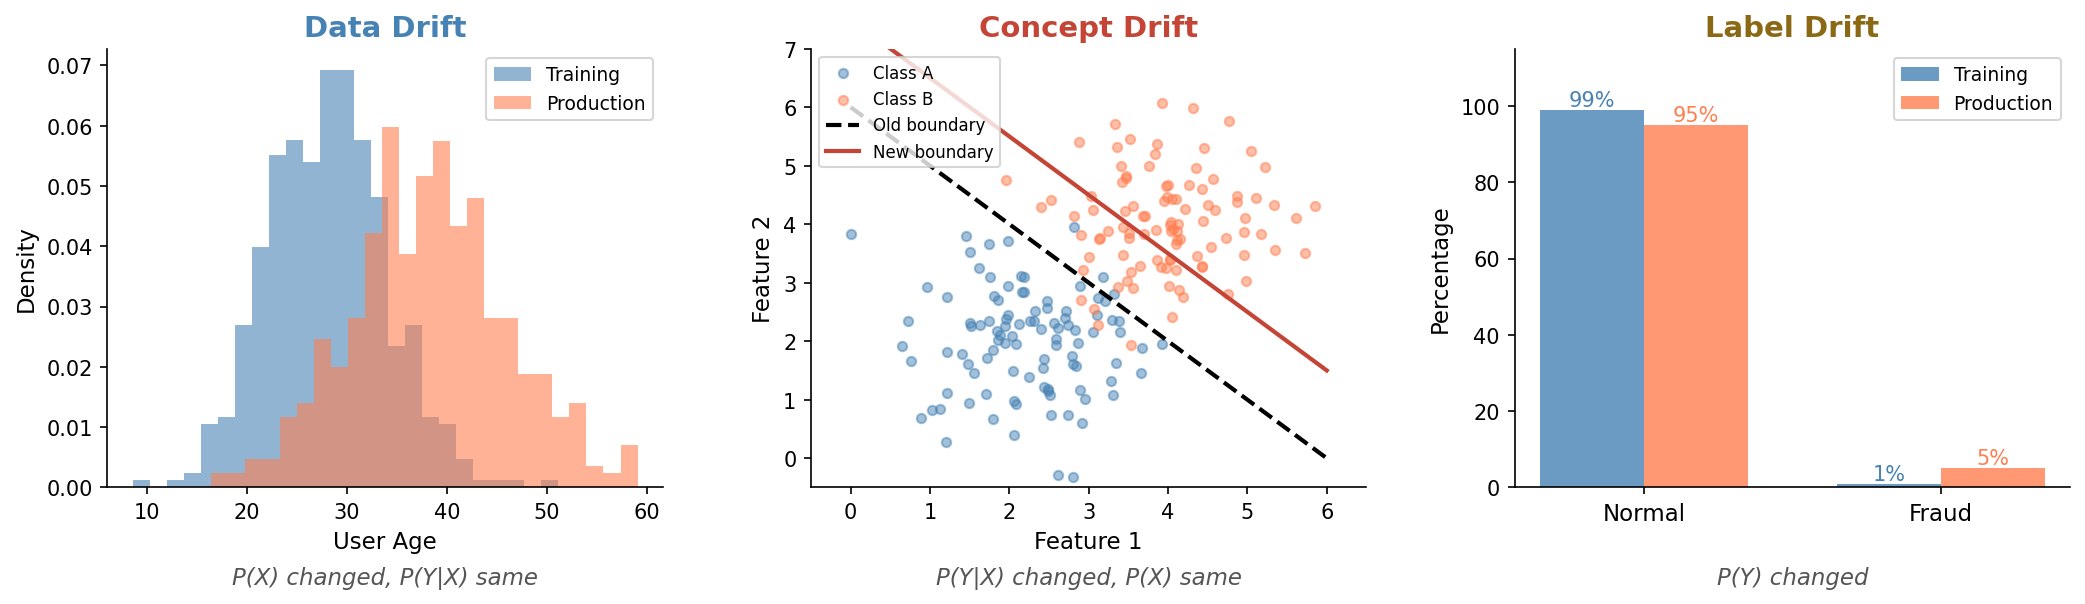

In [9]:
display(Image(filename=str(IMG / 'three_types_of_drift.png')))

## Part 7: What to Remember

A simple workflow for students:

1. Start with a plot
2. Ask what changed: inputs, rule, or class balance?
3. Use a statistical test only after the visual intuition is clear
4. Decide whether the issue is data drift, concept drift, label drift, or a pipeline bug
